# Modeling Atmospheric Oxygen Dynamics on Early Earth 

## Overview

This notebook simulates the delayed accumulation of atmospheric oxygen using a coupled system of **Ordinary Differential Equations (ODEs).** The model represents Cyanobacterial Oxygen production, oxidation of geological reservoir, and replenishment of reduced gases via volvanic outgassing. 

## Mathematical Framework 

**dB/dt = rB (1-B/K)** # ecological logistic growth 
where B(t) = Cyanobacteria biomass. 

**dO/dt = αB - γOR** 
where O(t) = Atmospheric Oxygen Concentration 

**dR/dt = V - γOR**
where R(t) = Reduced geological materials 

In [51]:
## import necessary Libraries

import numpy as np 
import matplotlib.pyplot as plt # differential equation solver
from scipy.integrate import solve_ivp 

## Parameter Definition and Initalization 

In [55]:
# cyanobacteria growth parameter
r = 0.5       # intrinsic growth rate
K = 10       # Carrying capacity

α = 0.3      # Oxygen production rate
γ = 0.2      # Oxidation rate constant

V = 0.5     # Volcanic flux

In [71]:
# Initial conditions
B0 = 0.1     # Initial cyanobacteria biomass
O0 = 0.01      # Initial oxygen concentration
R0 = 5.0      # Initial reduced reservoir
Y0 = [B0, O0, R0]

In [73]:
# time span for simulation

t_span = (0, 100)  
t_eval = np.linspace(0,100,500) # time points for evaluation

## ODE Definition 

In [75]:
def oxygen_model(t, Y, r, K, α, γ, V):

    B, O, R = Y

    dBdt = r*B*(1 - B/K)   #cyanobacteria logistic growth 
    dOdt = α*B - γ*O*R      #oxygen dynamics
    dRdt = V - γ*O*R       # Reduced reservior dynamics

    return [dBdt, dOdt, dRdt]

# solve the system
sol = solve_ivp(oxygen_model, 
                t_span, 
                Y0, 
                t_eval=t_eval,
                args= (r, K, α, γ, V)
               )

In [77]:
B= sol.y[0] 
O= sol.y[1] 
R= sol.y[2]

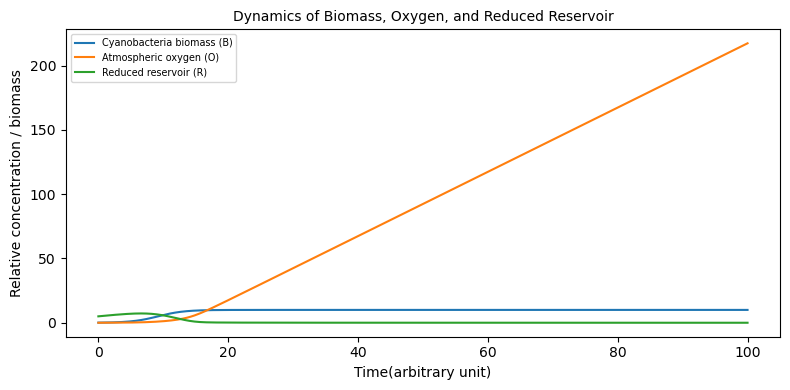

In [83]:
# system Dynamic plot 

plt.figure(figsize=(8,4))

plt.plot(t_eval, B, label="Cyanobacteria biomass (B)")
plt.plot(t_eval, O, label="Atmospheric oxygen (O)")
plt.plot(t_eval, R, label="Reduced reservoir (R)")

plt.xlabel("Time(arbitrary unit)")
plt.ylabel("Relative concentration / biomass")
plt.title("Dynamics of Biomass, Oxygen, and Reduced Reservoir", fontsize= 10)

plt.legend(fontsize= 'x-small')

plt.tight_layout()
plt.show()